In [1]:
#CELL 1: Environment setup and reproducibility

# Core libraries
import os
import sys
import platform
import random
import gc
import json
import psutil

# Data manipulation
import pandas as pd
import numpy as np

# Deep learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Machine learning
import lightgbm as lgb

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Global seed for reproducibility
def seed_everything(seed=42):
    """Fix random seeds for reproducibility."""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    
    # PyTorch seeds
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        # Deterministic CUDNN
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

SEED = 42
seed_everything(SEED)

# Log experimental environment
print("=== EXPERIMENTAL ENVIRONMENT ===")
print(f"OS: {platform.system()} {platform.release()}")
print(f"Python: {sys.version.split(' ')[0]}")
print(f"Device: {'GPU - ' + torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print("--- Library Versions ---")
print(f"Pandas  : {pd.__version__}")
print(f"Numpy   : {np.__version__}")
print(f"PyTorch : {torch.__version__}")
print(f"LightGBM: {lgb.__version__}")
print("===================================")
print(f"[Setup] Global seed set to {SEED}")
print("[Setup] Libraries loaded successfully!")

=== EXPERIMENTAL ENVIRONMENT ===
OS: Linux 6.6.122+
Python: 3.12.13
Device: GPU - Tesla T4
--- Library Versions ---
Pandas  : 2.3.3
Numpy   : 2.4.6
PyTorch : 2.10.0+cu128
LightGBM: 4.6.0
[Setup] Global seed set to 42
[Setup] Libraries loaded successfully!


In [2]:
# CELL 2: GLOBAL CONFIGURATIONS & DATA LOADING

# Global paths and split dates
DATA_PATH = '/kaggle/input/datasets/pgnjams/ie212-favorita-engineered-features-27-stores/kaggle/working/engineered_features_encoded_27_stores.parquet'
TRAIN_END = '2017-07-15'
VAL_END   = '2017-07-31'
TEST_END  = '2017-08-15'

print("Loading dataset:")
df = pd.read_parquet(DATA_PATH)
print(f"Original shape: {df.shape}")

# Drop unwanted columns
cols_to_drop = [col for col in df.columns if 'wavelet' in col]
cols_to_drop.extend(['time_idx', 'Unnamed: 0']) 
cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)
gc.collect()

# Downcast dtypes to optimize RAM
float_cols = df.select_dtypes(include=['float64']).columns
df[float_cols] = df[float_cols].astype('float32')
int_cols = df.select_dtypes(include=['int64']).columns
df[int_cols] = df[int_cols].astype('int32')

print(f"Shape after downcasting: {df.shape}")

Loading dataset:
Original shape: (18819628, 32)
Shape after downcasting: (18819628, 26)


In [3]:
# CELL 3: TRAIN / VAL / TEST SPLIT (WITH LSTM LOOKBACK)
df['date'] = pd.to_datetime(df['date'])
lookback_days = pd.Timedelta(days=15)
train_end_dt = pd.to_datetime(TRAIN_END)
val_end_dt = pd.to_datetime(VAL_END)

print("Splitting data: ")
train_df = df[df['date'] <= train_end_dt].copy()
val_df = df[(df['date'] > (train_end_dt - lookback_days)) & (df['date'] <= val_end_dt)].copy()
test_df = df[(df['date'] > (val_end_dt - lookback_days)) & (df['date'] <= pd.to_datetime(TEST_END))].copy()

print(f"Train samples: {train_df.shape[0]} | Val samples: {val_df.shape[0]} | Test samples: {test_df.shape[0]}")

# Free original dataframe to save memory
del df
gc.collect()

Splitting data: 
Train samples: 17265253 | Val samples: 1572613 | Test samples: 1501653


0

In [4]:
# CELL 3b: UTILITY - SUMMARY EXPORT & MEMORY TRACKING

# Export train summary for the report
try:
    train_df.describe().to_csv('/kaggle/working/train_summary.csv')
    print("Exported: train_summary.csv")
except Exception as e:
    print(f"Warning: Could not export summary. Error: {e}")

# Track memory usage
def get_mem(dataframe):
    mem = dataframe.memory_usage(deep=True).sum() / 1024**2
    return f"{mem:.2f} MB"

print("--- Memory Usage ---")
print(f"Train Set : {get_mem(train_df)}")
print(f"Val Set   : {get_mem(val_df)}")
print(f"Test Set  : {get_mem(test_df)}")

Exported: train_summary.csv
--- Memory Usage ---
Train Set : 1860.59 MB
Val Set   : 169.47 MB
Test Set  : 161.83 MB


In [5]:
# CELL 4: CORE LOGIC - PYTORCH DATASET & DATALOADERS

SEQ_LENGTH = 15
BATCH_SIZE = 1024

class SalesDataset(Dataset):
    def __init__(self, df, seq_length):
        # Sort data
        self.data = df.sort_values(by=['store_nbr', 'item_nbr', 'date']).reset_index(drop=True)
        self.seq_length = seq_length
        
        # Extract arrays
        self.features = self.data['kalman_sales'].values
        self.targets = self.data['unit_sales'].values
        
        # Apply perishable weights
        self.weights = np.where(self.data['perishable'].values == 1, 1.25, 1.0)
        
        self.stores = self.data['store_nbr'].values
        self.items = self.data['item_nbr'].values
        
        # Get valid sequences
        self.valid_indices = self._get_valid_indices()
        print(f"Valid sequences found: {len(self.valid_indices)}")
        
    def _get_valid_indices(self):
        mask = (self.stores[:-self.seq_length] == self.stores[self.seq_length:]) & \
               (self.items[:-self.seq_length] == self.items[self.seq_length:])
        return np.where(mask)[0]

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        start = self.valid_indices[idx]
        end = start + self.seq_length
        
        x = torch.tensor(self.features[start:end], dtype=torch.float32).unsqueeze(-1)
        y = torch.tensor(self.targets[end], dtype=torch.float32)
        w = torch.tensor(self.weights[end], dtype=torch.float32)
        
        return x, y, w

print("Initializing DataLoaders...")
train_loader = DataLoader(SalesDataset(train_df, SEQ_LENGTH), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(SalesDataset(val_df, SEQ_LENGTH), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print("DataLoaders ready.")

Initializing DataLoaders...
Valid sequences found: 16034518
Valid sequences found: 588076
DataLoaders ready.


In [6]:
# CELL 4b: UTILITY - DATALOADER MEMORY CHECK

process = psutil.Process(os.getpid())
mem_mb = process.memory_info().rss / 1024**2
print(f"Memory usage after DataLoaders: {mem_mb:.2f} MB")

try:
    with open('/kaggle/working/memory_log.txt', 'a') as f:
        f.write(f"Post-DataLoader Memory: {mem_mb:.2f} MB\n")
except Exception as e:
    pass

Memory usage after DataLoaders: 10176.00 MB


In [7]:
# CELL 5: CORE LOGIC - LSTM ARCHITECTURE & CUSTOM LOSS

class LSTMExtractor(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        # Extract last hidden state
        last_hidden_state = out[:, -1, :] 
        prediction = self.fc(last_hidden_state)
        return prediction.squeeze(-1), last_hidden_state

class NWRMSLELoss(nn.Module):
    def __init__(self):
        super().__init__()
        
    def forward(self, y_pred, y_true, weights):
        # Clamp to avoid log(0)
        y_pred = torch.clamp(y_pred, min=0.0)
        y_true = torch.clamp(y_true, min=0.0)
        
        # Calculate NWRMSLE
        squared_error = (torch.log1p(y_pred) - torch.log1p(y_true)) ** 2
        loss = torch.sum(weights * squared_error) / torch.sum(weights)
        return torch.sqrt(loss)

# Init model
model = LSTMExtractor()
print("Model and NWRMSLE loss initialized.")

Model and NWRMSLE loss initialized.


In [8]:
# CELL 5b: UTILITY - MODEL ARCHITECTURE & PARAMS EXPORT

model_summary = str(model)
total_params = sum(p.numel() for p in model.parameters())

print("--- MODEL ARCHITECTURE ---")
print(model_summary)
print(f"Total Parameters: {total_params}")

try:
    # Save architecture structure
    with open('/kaggle/working/model_architecture.txt', 'w') as f:
        f.write("LSTM Extractor Architecture:\n")
        f.write(model_summary)
    print("Saved: model_architecture.txt")
    
    # Save total parameters count
    with open('/kaggle/working/model_params.txt', 'w') as f:
        f.write(f"Total Parameters: {total_params}")
    print(f"Saved: model_params.txt (Params: {total_params})")
    
except Exception as e:
    print(f"Warning: Could not save model info. Error: {e}")

--- MODEL ARCHITECTURE ---
LSTMExtractor(
  (lstm): LSTM(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)
Total Parameters: 4513
Saved: model_architecture.txt
Saved: model_params.txt (Params: 4513)


In [9]:
# CELL 6: TRAIN LSTM 

# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = model.to(device)
criterion = NWRMSLELoss().to(device) 
optimizer = optim.Adam(model.parameters(), lr=0.001)

best_val_loss = float('inf')
epochs_no_improve = 0
train_losses, val_losses = [], []
patience = 2
max_epochs = 5

for epoch in range(max_epochs):
    model.train()
    running_train_loss = 0.0
    
    for x, y, w in train_loader:
        x, y, w = x.to(device), y.to(device), w.to(device)
        
        optimizer.zero_grad()
        preds, _ = model(x)
        
        loss = criterion(preds, y, w)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item()
        
    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for x, y, w in val_loader:
            x, y, w = x.to(device), y.to(device), w.to(device)
            preds, _ = model(x)
            running_val_loss += criterion(preds, y, w).item()
            
    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    print(f"Epoch {epoch+1} - Train loss: {avg_train_loss:.4f} - Val loss: {avg_val_loss:.4f}")
    
    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), '/kaggle/working/lstm_best.pth')
        print(" -> Model saved")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping triggered")
            break
            
    # Free GPU memory
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    gc.collect()

print(f"Training finished. Best val loss: {best_val_loss:.4f}")

Using device: cuda
Epoch 1 - Train loss: 0.5355 - Val loss: 0.5206
 -> Model saved
Epoch 2 - Train loss: 0.5149 - Val loss: 0.5172
 -> Model saved
Epoch 3 - Train loss: 0.5130 - Val loss: 0.5158
 -> Model saved
Epoch 4 - Train loss: 0.5119 - Val loss: 0.5147
 -> Model saved
Epoch 5 - Train loss: 0.5113 - Val loss: 0.5146
 -> Model saved
Training finished. Best val loss: 0.5146


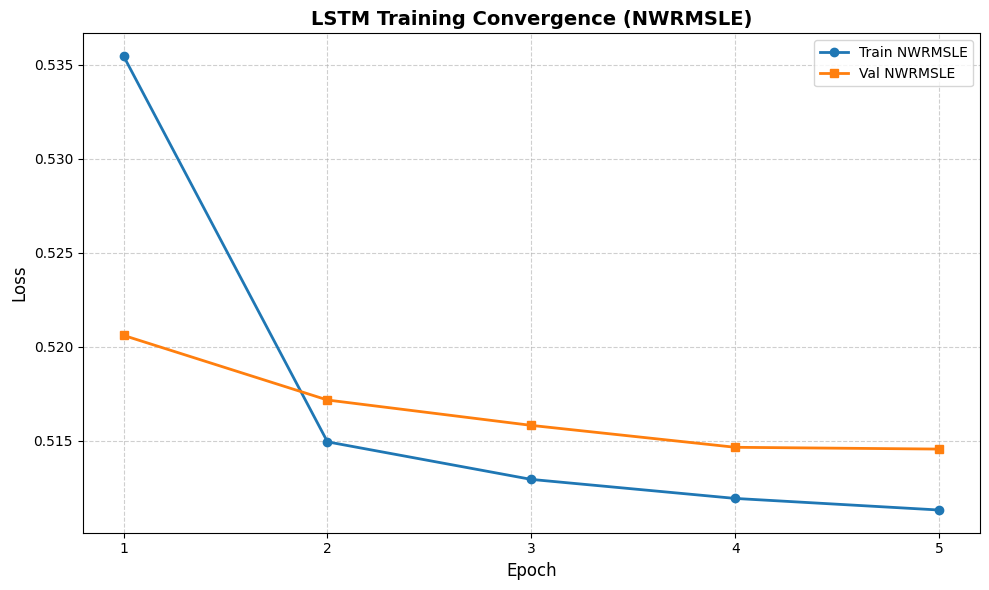

Saved: lstm_loss_curve.png
Saved: training_loss.csv


In [10]:
# CELL 6b: UTILITY - PLOT AND EXPORT TRAINING METRICS

# Export loss data
loss_df = pd.DataFrame({
    'epoch': range(1, len(train_losses) + 1), 
    'train_loss': train_losses, 
    'val_loss': val_losses
})
loss_df.to_csv('/kaggle/working/training_loss.csv', index=False)

# Plot convergence
plt.figure(figsize=(10, 6))
plt.plot(loss_df['epoch'], loss_df['train_loss'], label='Train NWRMSLE', marker='o', linewidth=2)
plt.plot(loss_df['epoch'], loss_df['val_loss'], label='Val NWRMSLE', marker='s', linewidth=2)

plt.title('LSTM Training Convergence (NWRMSLE)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(loss_df['epoch'])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Save plot
plt.savefig('/kaggle/working/lstm_loss_curve.png', dpi=300)
plt.show()

print("Saved: lstm_loss_curve.png")
print("Saved: training_loss.csv")

In [11]:
# CELL 7: CORE LOGIC - LSTM FEATURE EXTRACTION

# Load data
df_ext = pd.read_parquet(DATA_PATH)

# Drop unwanted columns
cols_to_drop = [c for c in df_ext.columns if 'lag' in c or 'rolling' in c or 'wavelet' in c]
df_ext.drop(columns=[c for c in cols_to_drop if c in df_ext.columns], inplace=True)
df_ext = df_ext.sort_values(by=['store_nbr', 'item_nbr', 'date']).reset_index(drop=True)

class ExtractionDataset(Dataset):
    def __init__(self, df, seq_length=15, target_col='kalman_sales'):
        self.seq_length = seq_length
        self.sales = df[target_col].values
        self.ids = df['id'].values
        
        stores = df['store_nbr'].values
        items = df['item_nbr'].values
        mask = (stores[:-self.seq_length] == stores[self.seq_length:]) & \
               (items[:-self.seq_length] == items[self.seq_length:])
        self.valid_indices = np.where(mask)[0]

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        start = self.valid_indices[idx]
        x = torch.tensor(self.sales[start:start+self.seq_length], dtype=torch.float32).unsqueeze(-1)
        return x, self.ids[start + self.seq_length]

# Prepare inference loader
ext_loader = DataLoader(ExtractionDataset(df_ext, SEQ_LENGTH), batch_size=4096, shuffle=False, num_workers=2, pin_memory=True)

# Load trained weights
model.load_state_dict(torch.load('/kaggle/working/lstm_best.pth'))
model.eval()

# Extraction
extracted_features, target_ids = [], []
with torch.no_grad():
    for x, ids in ext_loader:
        _, hidden = model(x.to(device))
        extracted_features.append(hidden.cpu().numpy())
        target_ids.extend(ids.numpy())

# Finalize and export
df_lstm = pd.DataFrame(np.vstack(extracted_features), columns=[f'lstm_feat_{i}' for i in range(32)])
df_lstm['id'] = target_ids
df_lstm.to_parquet('/kaggle/working/lstm_extracted_features.parquet', index=False)
print(f"Saved lstm_extracted_features.parquet with shape {df_lstm.shape}")

# Cleanup memory
del df_ext, df_lstm, extracted_features, target_ids
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

Saved lstm_extracted_features.parquet with shape (17579932, 33)


In [ ]:
# CELL read path
# Chạy trên kaggle đến cell 8 do lượng data xử lý merge lớn nên kernel tự động bị OOM
# Giải pháp :chạy lại cell 1 và cell này rồi chạy tiếp cell 8 về sau khi đã có file lstm_extracted_features.parquet để merge với lightgbm features
DATA_PATH = '/kaggle/input/datasets/pgnjams/ie212-favorita-engineered-features-27-stores/kaggle/working/engineered_features_encoded_27_stores.parquet'
print("Đã khai báo DATA_PATH")

Đã khai báo DATA_PATH


In [3]:
# Cell 8: Merge data by batch to save RAM
df_lstm = pd.read_parquet('/kaggle/working/lstm_extracted_features.parquet')
df_tab = pd.read_parquet(DATA_PATH)

# Drop wavelet and time columns for baseline
cols_to_drop = [c for c in df_tab.columns if 'wavelet' in c]
cols_to_drop.extend(['time_idx', 'Unnamed: 0'])
cols_to_drop = [c for c in cols_to_drop if c in df_tab.columns]
df_tab.drop(columns=cols_to_drop, inplace=True)

# Merge by store_nbr to keep consistency
all_merged = []
unique_stores = df_tab['store_nbr'].unique()

print(f"Merging {len(unique_stores)} stores...")
for store in unique_stores:
    subset_tab = df_tab[df_tab['store_nbr'] == store].copy()
    subset_merged = pd.merge(subset_tab, df_lstm, on='id', how='inner')
    all_merged.append(subset_merged)
    del subset_tab, subset_merged
    gc.collect()

df = pd.concat(all_merged)

del all_merged, df_tab, df_lstm
gc.collect()

process = psutil.Process(os.getpid())
print(f"RAM : {process.memory_info().rss / 1024**2:.2f} MB")

# Prepare final features for training
df = df.sort_values(by=['store_nbr', 'item_nbr', 'date']).reset_index(drop=True)
df['log_target'] = np.log1p(df['unit_sales'].clip(0))
df['weight'] = np.where(df['perishable'] == 1, 1.25, 1.0)
df['kalman_lag1'] = df.groupby(['store_nbr', 'item_nbr'])['kalman_sales'].shift(1)
print(f"Merge complete. Shape: {df.shape}")

Merging 27 stores...
RAM : 12179.73 MB
Merge complete. Shape: (17579932, 61)


In [4]:
# CELL 9: CORE LOGIC - LIGHTGBM TRAINING

import json

drop_cols = ['id', 'date', 'unit_sales', 'log_target', 'weight', 'kalman_sales']
features = [c for c in df.columns if c not in drop_cols]
print(f"Total features for LightGBM: {len(features)}")

df['date'] = pd.to_datetime(df['date'])
train_mask = df['date'] <= '2017-06-30'
val_mask = (df['date'] > '2017-06-30') & (df['date'] <= '2017-07-31')

print("Creating LightGBM datasets...")
dtrain = lgb.Dataset(df.loc[train_mask, features], 
                     label=df.loc[train_mask, 'log_target'], 
                     weight=df.loc[train_mask, 'weight'], 
                     free_raw_data=False)

dval = lgb.Dataset(df.loc[val_mask, features], 
                   label=df.loc[val_mask, 'log_target'], 
                   weight=df.loc[val_mask, 'weight'], 
                   reference=dtrain, 
                   free_raw_data=False)

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.02,
    'num_leaves': 80,
    'min_data_in_leaf': 200,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.7,
    'bagging_freq': 1,
    'verbose': -1,
    'seed': SEED
}

print("Starting LightGBM training...")
evals_result = {} 

gbm = lgb.train(params, dtrain, 
                num_boost_round=1500,
                valid_sets=[dtrain, dval],
                valid_names=['train', 'val'],
                callbacks=[
                    lgb.early_stopping(stopping_rounds=50), 
                    lgb.log_evaluation(50),
                    lgb.record_evaluation(evals_result) 
                ])

gbm.save_model('/kaggle/working/lgbm_model.txt')

actual_params = gbm.params
actual_params['best_iteration'] = gbm.best_iteration
with open('/kaggle/working/lgbm_actual_params.json', 'w') as f:
    json.dump(actual_params, f, indent=4)

Total features for LightGBM: 55
Creating LightGBM datasets...
Starting LightGBM training...
Training until validation scores don't improve for 50 rounds
[50]	train's rmse: 0.565596	val's rmse: 0.557621
[100]	train's rmse: 0.515093	val's rmse: 0.507418
[150]	train's rmse: 0.505935	val's rmse: 0.499378
[200]	train's rmse: 0.50282	val's rmse: 0.497933
[250]	train's rmse: 0.500724	val's rmse: 0.497883
Early stopping, best iteration is:
[221]	train's rmse: 0.501867	val's rmse: 0.497836


Exported: feature_importance.csv


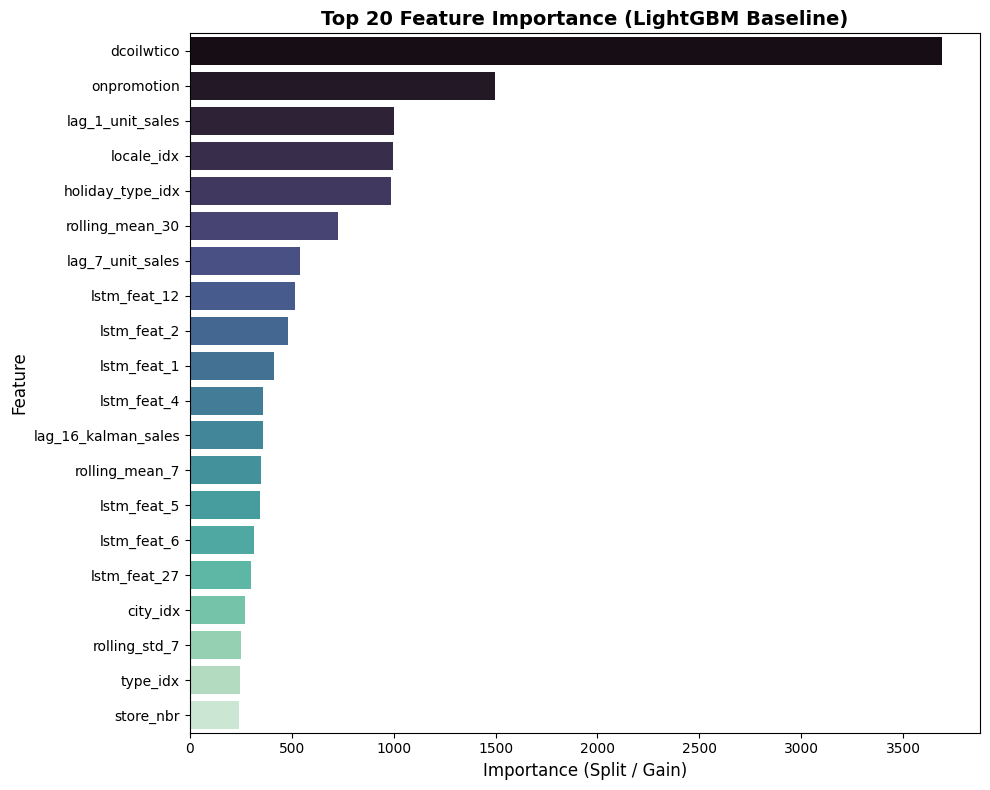

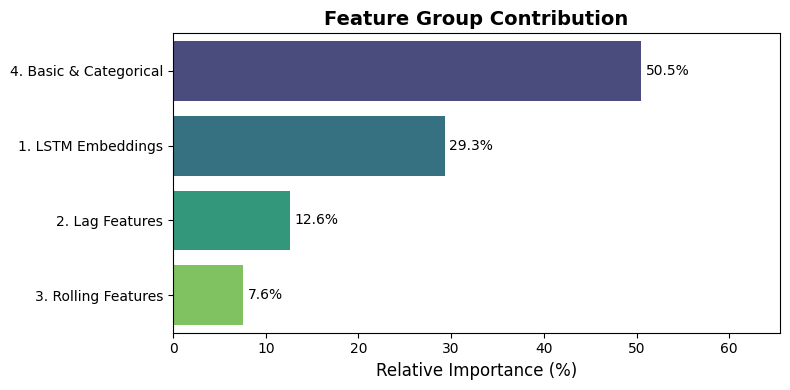


--- TỶ TRỌNG ĐÓNG GÓP THEO NHÓM ---
4. Basic & Categorical         : 50.48%
1. LSTM Embeddings             : 29.32%
2. Lag Features                : 12.61%
3. Rolling Features            : 7.59%


In [5]:
# CELL 9b: UTILITY - FEATURE IMPORTANCE ANALYSIS & PLOTS

# 1. Export basic importance to CSV
importance = pd.DataFrame({'feature': features, 'importance': gbm.feature_importance()})
importance = importance.sort_values(by='importance', ascending=False)

try:
    importance.to_csv('/kaggle/working/feature_importance.csv', index=False)
    print("Exported: feature_importance.csv")
except Exception as e:
    pass

# 2. PLOT: Top 20 Individual Features
plt.figure(figsize=(10, 8))
# FIX: Thêm hue='feature' và legend=False
sns.barplot(x='importance', y='feature', hue='feature', data=importance.head(20), palette='mako', legend=False)
plt.title('Top 20 Feature Importance (LightGBM Baseline)', fontsize=14, fontweight='bold')
plt.xlabel('Importance (Split / Gain)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
try:
    plt.savefig('/kaggle/working/top_20_features.png', dpi=300)
except:
    pass
plt.show()

# 3. PLOT & CALCULATE: Grouped Feature Importance
def categorize_feature(feat_name):
    if 'lstm_feat' in feat_name: return '1. LSTM Embeddings'
    elif 'lag' in feat_name: return '2. Lag Features'
    elif 'roll' in feat_name or 'std' in feat_name or 'mean' in feat_name: return '3. Rolling Features'
    else: return '4. Basic & Categorical'

importance['feature_group'] = importance['feature'].apply(categorize_feature)
grouped_imp = importance.groupby('feature_group')['importance'].sum().reset_index()
grouped_imp['importance_percent'] = (grouped_imp['importance'] / grouped_imp['importance'].sum()) * 100
grouped_imp = grouped_imp.sort_values(by='importance_percent', ascending=False)

plt.figure(figsize=(8, 4))
# FIX: Thêm hue='feature_group' và legend=False
sns.barplot(x='importance_percent', y='feature_group', hue='feature_group', data=grouped_imp, palette='viridis', legend=False)
plt.title('Feature Group Contribution', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance (%)', fontsize=12)
plt.ylabel('')

# Add percentage labels directly on the bars
for index, value in enumerate(grouped_imp['importance_percent']):
    plt.text(value + 0.5, index, f'{value:.1f}%', va='center')

plt.xlim(0, max(grouped_imp['importance_percent']) + 15)
plt.tight_layout()

try:
    plt.savefig('/kaggle/working/grouped_features.png', dpi=300)
except:
    pass
plt.show()

# 4. PRINT: Tỷ trọng đóng góp 
print("\n--- TỶ TRỌNG ĐÓNG GÓP THEO NHÓM ---")
for idx, row in grouped_imp.iterrows():
    print(f"{row['feature_group']:<30} : {row['importance_percent']:.2f}%")

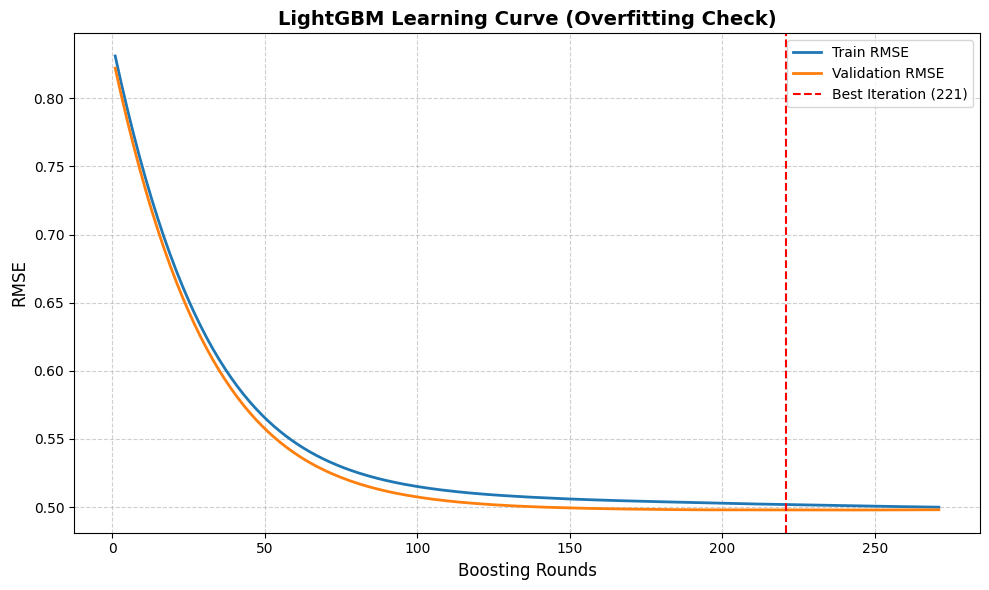

In [6]:
# CELL 9c: UTILITY - LIGHTGBM LEARNING CURVE

train_rmse = evals_result['train']['rmse']
val_rmse = evals_result['val']['rmse']
epochs_range = range(1, len(train_rmse) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, train_rmse, label='Train RMSE', linewidth=2)
plt.plot(epochs_range, val_rmse, label='Validation RMSE', linewidth=2)

# point Early Stopping
best_iter = gbm.best_iteration
plt.axvline(x=best_iter, color='red', linestyle='--', label=f'Best Iteration ({best_iter})')

plt.title('LightGBM Learning Curve (Overfitting Check)', fontsize=14, fontweight='bold')
plt.xlabel('Boosting Rounds', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/kaggle/working/lgbm_learning_curve.png', dpi=300)
plt.show()

In [12]:

# CELL 10: CORE LOGIC - INFERENCE, METRICS & EXPORT FOR STREAMLIT


test_start = '2017-08-01'

print("Extracting test data...")
if not pd.api.types.is_datetime64_any_dtype(df['date']):
    df['date'] = pd.to_datetime(df['date'])
    
test_mask = df['date'] >= test_start
test_df = df[test_mask].copy()

# run inference
print("Running inference...")
preds_log = gbm.predict(test_df[features])
preds = np.expm1(preds_log)

# clean predictions
preds = np.clip(preds, a_min=0.0, a_max=None)
preds = np.round(preds, 4)

# prep actuals and weights
actuals = test_df['unit_sales'].values
weights = test_df['weight'].values

# calc metrics
print("Calculating test metrics...")
log_preds = np.log1p(preds)
log_actuals = np.log1p(actuals)

# custom metrics
nwrmsle = np.sqrt(np.sum(weights * (log_preds - log_actuals)**2) / np.sum(weights))
wmae = np.sum(weights * np.abs(actuals - preds)) / np.sum(weights)
wrmse = np.sqrt(np.sum(weights * (actuals - preds)**2) / np.sum(weights))

print("\n==================================")
print("--- FINAL BASELINE TEST METRICS ---")
print("==================================")
print(f"NWRMSLE : {nwrmsle:.4f}")
print(f"WMAE    : {wmae:.4f}")
print(f"WRMSE   : {wrmse:.4f}")
print("==================================")

metrics_dict = {
    "NWRMSLE": round(nwrmsle, 4),
    "WMAE": round(wmae, 4),
    "WRMSE": round(wrmse, 4)
}
with open('/kaggle/working/track1_metrics.json', 'w') as f:
    json.dump(metrics_dict, f, indent=4)

# format export dataframe 
out_df = pd.DataFrame()
out_df['date'] = test_df['date'].dt.strftime('%Y-%m-%d')
out_df['store_nbr'] = test_df['store_nbr'].values
out_df['item_nbr'] = test_df['item_nbr'].values
out_df['actual_sales'] = actuals        
out_df['predicted_sales'] = preds       

# save output 
out_file = '/kaggle/working/preds_track1.csv'
out_df.to_csv(out_file, index=False)
print(f"Saved for Streamlit: {out_file}")



Extracting test data...
Running inference...
Calculating test metrics...

--- FINAL BASELINE TEST METRICS ---
NWRMSLE : 0.4944
WMAE    : 3.0460
WRMSE   : 11.2781
Saved for Streamlit: /kaggle/working/preds_track1.csv



[Plot Sync] Cố định biểu đồ tại Store: 3, Item: 1503844


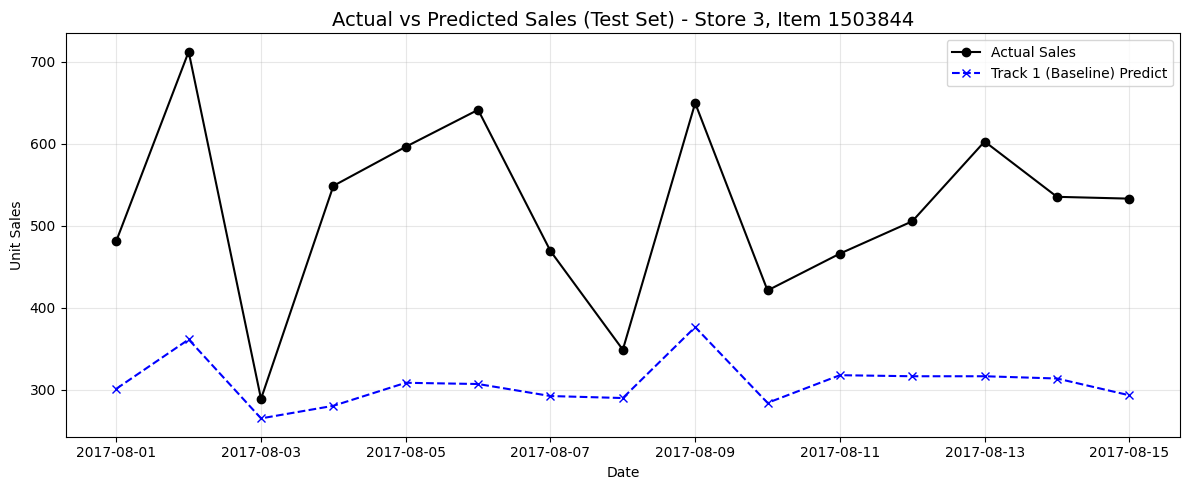

-> Đã lưu 'plot_data_track1.csv' chờ gộp.


3978

In [13]:
# CELL 11: UNIFIED PLOTTING LOGIC (FIXED STORE-ITEM) - TRACK 1
import matplotlib.pyplot as plt

# Cố định ID tại đây để so sánh công bằng giữa các Track
PLOT_STORE = 3  
PLOT_ITEM = 1503844  

print(f"\n[Plot Sync] Cố định biểu đồ tại Store: {PLOT_STORE}, Item: {PLOT_ITEM}")

# Lọc dữ liệu trực tiếp từ out_df (đã có sẵn ở Cell 10)
plot_df = out_df[(out_df['store_nbr'] == PLOT_STORE) & (out_df['item_nbr'] == PLOT_ITEM)].copy()
plot_df['date'] = pd.to_datetime(plot_df['date'])

# Vẽ biểu đồ riêng cho Track 1 (Dùng màu Xanh dương)
plt.figure(figsize=(12, 5))
plt.plot(plot_df['date'], plot_df['actual_sales'], label='Actual Sales', marker='o', color='black')
plt.plot(plot_df['date'], plot_df['predicted_sales'], label='Track 1 (Baseline) Predict', marker='x', color='blue', linestyle='--')
plt.title(f'Actual vs Predicted Sales (Test Set) - Store {PLOT_STORE}, Item {PLOT_ITEM}', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/track1_forecast_plot_fixed.png', dpi=300)
plt.show()

# Lưu file CSV trung gian chờ gộp với các phương pháp khác
merge_df = plot_df[['date', 'actual_sales', 'predicted_sales']].rename(columns={'predicted_sales': 'Track1_Pred'})
merge_df.to_csv('/kaggle/working/plot_data_track1.csv', index=False)

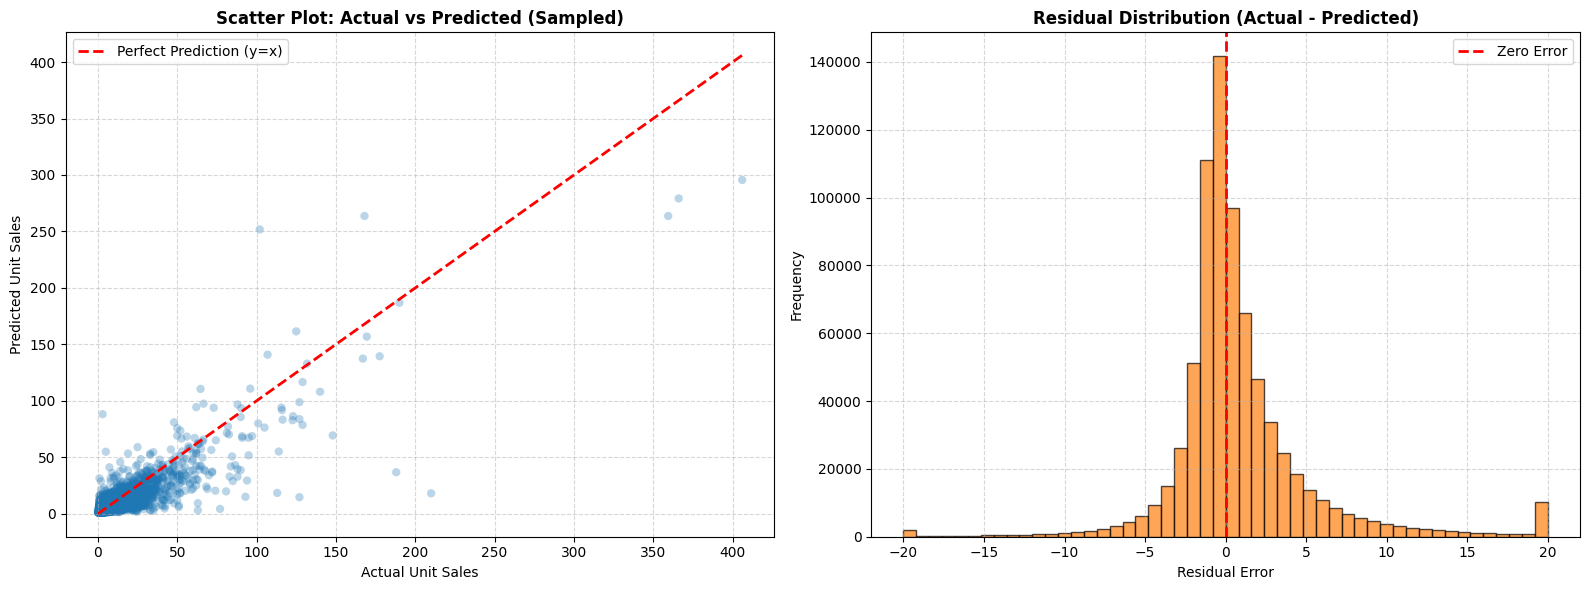

Đã lưu biểu đồ: /kaggle/working/residual_analysis.png


48

In [14]:
# cell 12: plot actual vs predicted scatter and residual distribution
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import gc

# Load dữ liệu chuẩn từ kaggle/working
df_plot = pd.read_csv('/kaggle/working/preds_track1.csv')

# to avoid cluttering with 750k points, we sample 10,000 random points for the scatter plot
df_sample = df_plot.sample(n=10000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# subplot 1: scatter plot (actual vs predicted)
axes[0].scatter(df_sample['actual_sales'], df_sample['predicted_sales'], alpha=0.3, color='#1f77b4', edgecolors='none')
# plot the perfect prediction diagonal line (y=x)
max_val = max(df_sample['actual_sales'].max(), df_sample['predicted_sales'].max())
axes[0].plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction (y=x)')

axes[0].set_title('Scatter Plot: Actual vs Predicted (Sampled)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Actual Unit Sales', fontsize=10)
axes[0].set_ylabel('Predicted Unit Sales', fontsize=10)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# subplot 2: residual error distribution
# residual = actual - predicted
df_plot['residual'] = df_plot['actual_sales'] - df_plot['predicted_sales']
# limit to (-20, 20) range to ignore extreme outliers for clear visualization
residuals_clipped = df_plot['residual'].clip(lower=-20, upper=20)

axes[1].hist(residuals_clipped, bins=50, color='#ff7f0e', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')

axes[1].set_title('Residual Distribution (Actual - Predicted)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Residual Error', fontsize=10)
axes[1].set_ylabel('Frequency', fontsize=10)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('/kaggle/working/residual_analysis.png', dpi=300)
plt.show()

print("Đã lưu biểu đồ: /kaggle/working/residual_analysis.png")

# Giải phóng RAM
del df_plot, df_sample
gc.collect()

In [16]:
# CELL 13: EXPORT RAW DATA ARTIFACTS FOR FINAL CROSS-TRACK COMPARISON
import pandas as pd
import json

print("Exporting cross-track artifacts...")

# 1. Export feature importance scores
importance_scores = gbm.feature_importance(importance_type='split')
feature_names = gbm.feature_name()

df_importance = pd.DataFrame({
    'feature': feature_names,
    'importance_split': importance_scores 
})

# Sort và lưu top 50
df_importance = df_importance.sort_values('importance_split', ascending=False).head(50)
df_importance.to_csv('/kaggle/working/track1_kalman_importance.csv', index=False)
print("-> Đã lưu: /kaggle/working/track1_kalman_importance.csv")

# 2. Export final metrics 
if 'nwrmsle' in locals():
    metrics_dict = {
        "track": "Track 1: Kalman + LSTM + LightGBM",
        "nwrmsle": float(nwrmsle),
        "wmae": float(wmae),
        "wrmse": float(wrmse)
    }

    with open('/kaggle/working/track1_metrics.json', 'w') as f:
        json.dump(metrics_dict, f, indent=4)
    print("-> Đã lưu: /kaggle/working/track1_metrics.json")
else:
    print("Không tìm thấy biến metrics.")

print("\nAll cross-track artifacts exported successfully! Ready for final comparison.")

Exporting cross-track artifacts...
-> Đã lưu: /kaggle/working/track1_kalman_importance.csv
-> Đã lưu: /kaggle/working/track1_metrics.json

All cross-track artifacts exported successfully! Ready for final comparison.


In [20]:
# CELL 14: EXPORT, ARCHIVE & PREPARE FOR DOWNLOAD (AUTOMATIC)
import os
import zipfile
from IPython.display import FileLink

zip_filename = 'track1_results_archive.zip'

print(f"--- Archiving all artifacts into {zip_filename} ---")

# Tự động lấy danh sách file cần nén
files_to_zip = []

# Duyệt qua thư mục để lấy tất cả file .csv, .json, .png, .txt
for file in os.listdir('/kaggle/working/'):
    if file.endswith(('.csv', '.json', '.png', '.txt', '.pth')):
        files_to_zip.append(file)

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for file in files_to_zip:
        file_path = os.path.join('/kaggle/working/', file)
        zipf.write(file_path, arcname=file)
        print(f"Added: {file}")

# Tạo link tải
if os.path.exists(zip_filename):
    print("\n>>> ARCHIVE COMPLETE! <<<")
    display(FileLink(zip_filename))
else:
    print("\nLỗi: Không tạo được file zip.")

--- Archiving all artifacts into track1_results_archive.zip ---
Added: train_summary.csv
Added: track1_forecast_plot_fixed.png
Added: lgbm_actual_params.json
Added: track1_kalman_importance.csv
Added: lstm_best.pth
Added: lgbm_model.txt
Added: plot_data_track1.csv
Added: grouped_features.png
Added: residual_analysis.png
Added: track1_metrics.json
Added: top_20_features.png
Added: preds_track1.csv
Added: training_loss.csv
Added: feature_importance.csv
Added: lstm_loss_curve.png
Added: model_architecture.txt
Added: lgbm_learning_curve.png
Added: memory_log.txt
Added: model_params.txt

>>> ARCHIVE COMPLETE! <<<


/kaggle/working/track1_results_archive.zip

In [19]:
import os
print(os.path.exists('/kaggle/working/track1_results_archive.zip'))
print(os.path.getsize('/kaggle/working/track1_results_archive.zip'))

True
27523214


In [ ]:
# # CELL: TỔNG HỢP VÀ VẼ BIỂU ĐỒ SO SÁNH 3 MÔ HÌNH 
# import pandas as pd
# import matplotlib.pyplot as plt

# # 1. Nạp 3 file từ 3 mô hình
# df1 = pd.read_csv('track1_baseline_plot.csv')
# df2 = pd.read_csv('track2_wavelet_plot.csv')
# df3 = pd.read_csv('track3_tft_plot.csv')

# # 2. Gộp chúng lại (Merge theo date)
# df_final = df1.merge(df2[['date', 'pred_wavelet']], on='date', how='left')
# df_final = df_final.merge(df3[['date', 'pred_tft']], on='date', how='left')
# df_final['date'] = pd.to_datetime(df_final['date'])

# # 3. Vẽ biểu đồ tổng
# plt.figure(figsize=(14, 7))
# plt.plot(df_final['date'], df_final['actual_sales'], label='Actual Sales', color='black', marker='o', linewidth=3)
# plt.plot(df_final['date'], df_final['pred_baseline'], label='Track 1: Baseline', color='blue', linestyle='--')
# plt.plot(df_final['date'], df_final['pred_wavelet'], label='Track 2: Wavelet', color='green', linestyle='-.')
# plt.plot(df_final['date'], df_final['pred_tft'], label='Track 3: TFT', color='red', linestyle=':')

# plt.title('Mô hình Hợp nhất: Dự báo Doanh số Chuỗi Cung Ứng', fontsize=16, fontweight='bold')
# plt.xlabel('Ngày', fontsize=12)
# plt.ylabel('Doanh số (Unit Sales)', fontsize=12)
# plt.legend(fontsize=11)
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.savefig('final_comparison_plot.png', dpi=300)
# plt.show()